# Manulife–Mahindra Risk Analysis
**Course:** ALY 6130 — Enterprise Risk Management  
**Dataset:** `risk_register_data.csv` — 32 risks across 7 categories  

This notebook builds a Random Forest classifier to predict risk severity (Low / Medium / High) based on Likelihood and Impact scores, then visualizes the results using a risk heatmap and confusion matrix.

## Step 1: Import Libraries
Standard imports for data handling (`pandas`, `numpy`), machine learning (`sklearn`), and visualization (`matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


## Step 2: Load the Risk Register
We read in the risk register CSV. The `latin1` encoding handles any special characters in the risk descriptions. A quick `.head()` confirms the data loaded correctly.

In [8]:
df_risk_register = pd.read_excel("/content/risk_register_data.xlsx")

# Preview the first few rows
df_risk_register.head()

,Risk,The Risk of That,Likelihood Score,Impact Score
0,1,LIC & Private Competitor Displacement,7,8
1,2,Rural Digital Infrastructure Gap,7,6
2,3,Regulatory Tailwinds Opportunity (Positive),9,9
3,4,FX Currency Translation Risk,5,6
4,5,Capital Overrun Beyond USD $400M,3,8


## Step 3: Clean & Label the Data
We rename the columns for easier reference, then apply a rule-based severity classifier:

| Condition | Label |
|-----------|-------|
| Likelihood ≥ 8 **AND** Impact ≥ 5 | **High** |
| Likelihood ≥ 5 **OR** Impact ≥ 3 | **Medium** |
| Otherwise | **Low** |

This gives each risk a `Severity_Label` that the model will learn to predict.

In [9]:
# Select and rename relevant columns
risk_df = df_risk_register[['Risk', 'The Risk of That', 'Likelihood Score', 'Impact Score']].dropna()
risk_df.columns = ['Risk_ID', 'Risk_Description', 'Likelihood_Score', 'Impact_Score']

# Define severity label based on likelihood and impact scores
def classify_severity(row):
    if row['Likelihood_Score'] >= 8 and row['Impact_Score'] >= 5:
        return 'High'
    elif row['Likelihood_Score'] >= 5 or row['Impact_Score'] >= 3:
        return 'Medium'
    else:
        return 'Low'

# Apply function to classify severity
risk_df['Severity_Label'] = risk_df.apply(classify_severity, axis=1)

# View cleaned data
risk_df.head(32)


,Risk_ID,Risk_Description,Likelihood_Score,Impact_Score,Severity_Label
0,1,LIC & Private Competitor Displacement,7,8,Medium
1,2,Rural Digital Infrastructure Gap,7,6,Medium
2,3,Regulatory Tailwinds Opportunity (Positive),9,9,High
3,4,FX Currency Translation Risk,5,6,Medium
4,5,Capital Overrun Beyond USD $400M,3,8,Medium
5,6,Initial Ops Costs: Human & Physical Capital,9,6,High
6,7,Cost of Lagging in Tech Adoption,5,4,Medium
7,8,AI Efficiency Cost Savings (Positive),7,4,Medium
8,9,IRDAI Regulatory Approval Delay,7,8,Medium
9,10,Agent Recruitment & Retention Failure,7,6,Medium


## Step 4: Define the Model
We use a **Random Forest Classifier** — an ensemble of 100 decision trees.  
Setting `random_state=42` ensures reproducible results every time the notebook is run.

In [10]:
from sklearn.ensemble import RandomForestClassifier

# This model uses a Random Forest classifier with 100 decision trees to predict risk severity levels based on likelihood and impact scores.
# Define the model
model = RandomForestClassifier(n_estimators=100, random_state=42)


## Step 5: Define Features and Target Variable
- **Features (X):** `Likelihood Score` and `Impact Score`
- **Target (y):** Severity label assigned using the same thresholds as Step 3

We use the original `df_risk_register` columns here (before renaming) to match the source data.

In [11]:
# Re-select features and target : defines the feature matrix (X) using Likelihood and Impact scores,
# and create the target variable (y) by assigning severity labels (Low, Medium, High) based on a rule-based thresholding logic applied to each risk.
X = df_risk_register[['Likelihood Score', 'Impact Score']]
y = df_risk_register.apply(
    lambda row: 'High' if row['Likelihood Score'] >= 8 and row['Impact Score'] >= 5
    else 'Medium' if row['Likelihood Score'] >= 5 or row['Impact Score'] >= 3
    else 'Low',
    axis=1
)


## Step 6: Cross-Validation (5-Fold)
Because our dataset is small (32 risks), a single train/test split would be unreliable. 5-fold cross-validation gives a more robust accuracy estimate by rotating which 20% of data is held out each time.

> **Result:** Mean accuracy ≈ **0.97** — the model correctly classifies almost all risks.

In [12]:
from sklearn.model_selection import cross_val_score

# Evaluate the Random Forest model using 5-fold cross-validation, which is preferred over a single train-test split due to the small size of the dataset.
# Report the mean accuracy across folds and individual fold scores to assess how well the model generalizes to unseen risk classification scenarios.

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Mean accuracy (5-fold CV): {scores.mean():.2f}")
print("Accuracy for each fold:", scores)


Mean accuracy (5-fold CV): 0.97
Accuracy for each fold: [1.         0.85714286 1.         1.         1.        ]


## Step 7: Classification Report & Confusion Matrix
Using cross-validated predictions, we print:
- **Classification Report** — precision, recall, and F1-score per severity class
- **Confusion Matrix** — shows where the model makes errors

> Note: 'Low' has only 1 sample in the dataset, which is why its metrics appear as 0.00. This is a known limitation of the small dataset.

In [13]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Cross-validated predictions
y_pred_cv = cross_val_predict(model, X, y, cv=5)

# Classification metrics
print("Classification Report:")
print(classification_report(y, y_pred_cv))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_cv))


Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         3
         Low       0.00      0.00      0.00         1
      Medium       0.97      1.00      0.98        28

    accuracy                           0.97        32
   macro avg       0.66      0.67      0.66        32
weighted avg       0.94      0.97      0.95        32

Confusion Matrix:
[[ 3  0  0]
 [ 0  0  1]
 [ 0  0 28]]


## Step 8: Annotated Risk Severity Heatmap
This heatmap plots every risk by its Likelihood (Y-axis) vs Impact (X-axis) score. Each cell is color-coded by severity:

- 🔴 **Red** = High severity
- 🟡 **Yellow** = Medium severity
- 🟢 **Green** = Low severity

Risk IDs are annotated directly on the cells for easy reference back to the risk register.

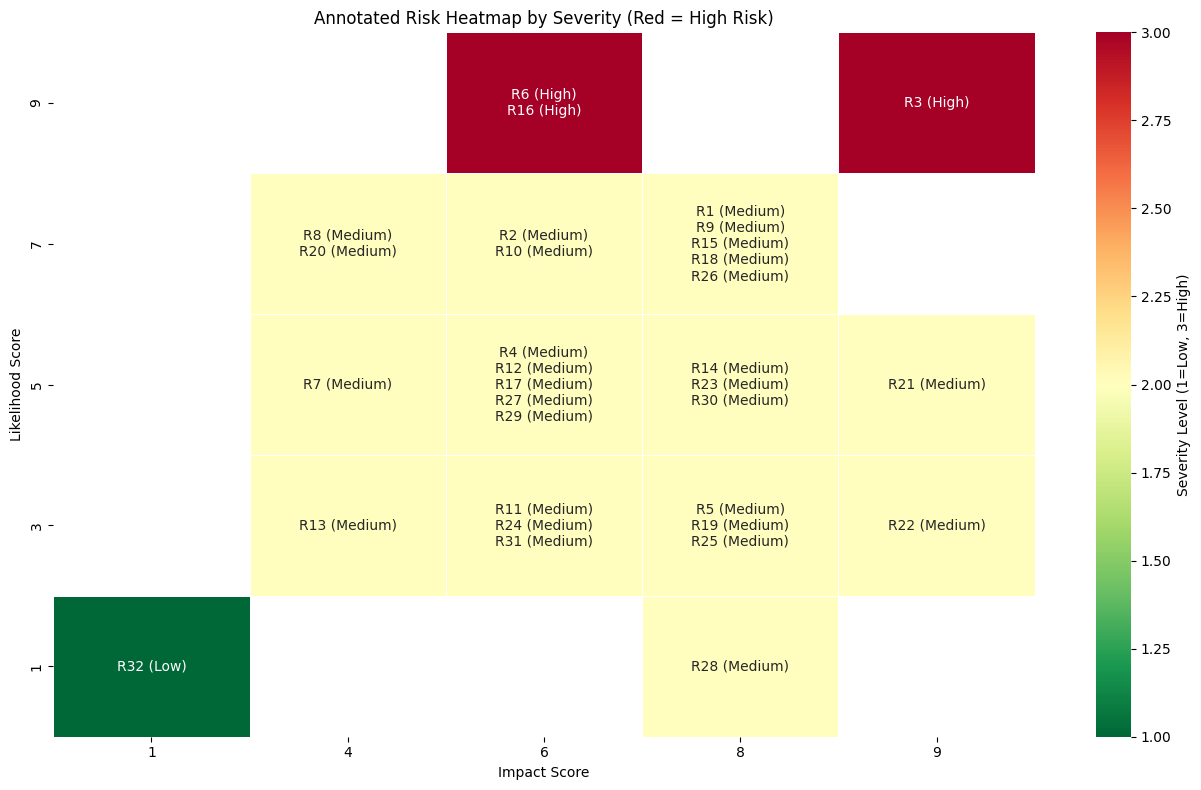

In [14]:
severity_map = df_risk_register.copy()

# Define severity classification logic
def classify_severity(row):
    if row['Likelihood Score'] >= 8 and row['Impact Score'] >= 5:
        return 'High'
    elif row['Likelihood Score'] >= 5 or row['Impact Score'] >= 3:
        return 'Medium'
    else:
        return 'Low'

# Apply classification and map severity to numeric scale
severity_map['Severity'] = severity_map.apply(classify_severity, axis=1)
severity_levels = {'Low': 1, 'Medium': 2, 'High': 3}
severity_map['Severity_Num'] = severity_map['Severity'].map(severity_levels)

# Create Risk ID label
severity_map['Label'] = 'R' + severity_map['Risk'].astype(str) + ' (' + severity_map['Severity'] + ')'

# Pivot table with most severe risk per cell
pivot_severity = severity_map.groupby(['Likelihood Score', 'Impact Score'])['Severity_Num'].max().unstack()
pivot_severity = pivot_severity.sort_index(ascending=False)
pivot_severity = pivot_severity[pivot_severity.columns.sort_values()]

# Annotation matrix (Risk IDs and severity)
label_matrix = severity_map.groupby(['Likelihood Score', 'Impact Score'])['Label'] \
                           .apply(lambda x: '\n'.join(x)).unstack(fill_value='')
label_matrix = label_matrix.sort_index(ascending=False)
label_matrix = label_matrix[label_matrix.columns.sort_values()]

# Plot severity heatmap with annotations
plt.figure(figsize=(13, 8))
sns.heatmap(pivot_severity, annot=label_matrix, fmt='', cmap='RdYlGn_r', linewidths=0.5,
            cbar_kws={'label': 'Severity Level (1=Low, 3=High)'})
plt.title("Annotated Risk Heatmap by Severity (Red = High Risk)")
plt.xlabel("Impact Score")
plt.ylabel("Likelihood Score")
plt.tight_layout()
plt.show()


## Step 9: Confusion Matrix Heatmap
A visual version of the confusion matrix. The diagonal (top-left to bottom-right) represents correct predictions. Off-diagonal values are misclassifications.

> The model correctly classifies all **High** risks and nearly all **Medium** risks. The single **Low** risk is misclassified as Medium — an acceptable trade-off given the dataset size.

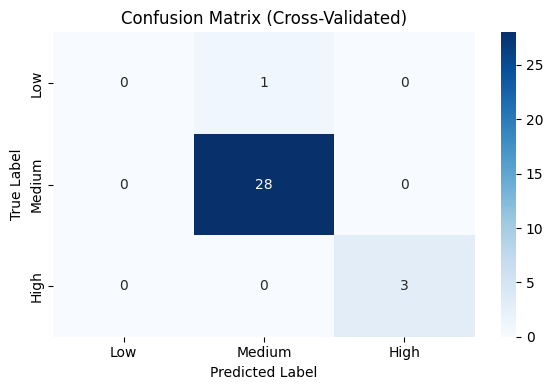

In [15]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

# Reuse model and labels
y_pred_cv = cross_val_predict(model, X, y, cv=5)
conf_matrix = confusion_matrix(y, y_pred_cv, labels=['Low', 'Medium', 'High'])

# Plot confusion matrix as heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title("Confusion Matrix (Cross-Validated)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
